# Similarity-Pruned Dataset Workflow

Select one random anchor graph, compute vectorized embeddings for all graphs,
define a regression target as cosine similarity to that anchor,
remove the top-`k` most similar graphs, and continue with the pruned dataset.


In [1]:
%matplotlib inline
import math
import hashlib
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from NSPPK.nsppk import NSPPK

from coco_grape.visualizer.mol_display import draw_molecules

try:
    from notebooks.notebook_utils import (
        infer_display_mode,
        plot_networkx_graphs,
        plot_similarity_distribution_with_iqr,
    )
except ModuleNotFoundError:
    from notebook_utils import (
        infer_display_mode,
        plot_networkx_graphs,
        plot_similarity_distribution_with_iqr,
    )


In [2]:
# Plot/display helpers moved to notebooks/notebook_utils.py


In [3]:
# Configuration
DATASET_TYPE = 'MOLECULAR'  # 'MOLECULAR' or 'ARTIFICIAL'
DATASET_SIZE = 2000
RANDOM_STATE = 42
K_REMOVE = 5
REMOVE_ANCHOR = False
MAX_NODE_SIZE = 28

# Molecular loader config
ASSAY_ID = '651610'


In [4]:
# Dataset builder moved to notebooks/demo_pipeline_utils.py
try:
    from notebooks.demo_pipeline_utils import build_dataset
except ModuleNotFoundError:
    from demo_pipeline_utils import build_dataset


In [5]:
def compute_graph_embeddings(graphs, nbits=11):
    graph_vectorizer = NSPPK(
        radius=2,
        distance=4,
        connector=1,
        nbits=nbits,
        dense=True,
        parallel=True,
        use_edges_as_features=True,
    )
    embeddings = np.asarray(graph_vectorizer.fit_transform(graphs), dtype=np.float32)
    return graph_vectorizer, embeddings


def prune_by_anchor_similarity(graphs, targets, embeddings, k_remove=5, random_state=42, remove_anchor=False):
    if len(graphs) == 0:
        raise ValueError("Cannot prune an empty dataset.")
    if k_remove < 0:
        raise ValueError("k_remove must be >= 0.")
    if k_remove >= len(graphs):
        raise ValueError("k_remove must be smaller than the dataset size.")

    rng = np.random.default_rng(random_state)
    anchor_idx = int(rng.integers(low=0, high=len(graphs)))

    anchor_vec = embeddings[anchor_idx:anchor_idx + 1]
    similarity = cosine_similarity(embeddings, anchor_vec).ravel()

    ranking = np.argsort(-similarity)
    ordered = [idx for idx in ranking if (remove_anchor or idx != anchor_idx)]
    remove_indices = np.asarray(ordered[:k_remove], dtype=int)

    keep_mask = np.ones(len(graphs), dtype=bool)
    keep_mask[remove_indices] = False

    pruned_graphs = [g for g, keep in zip(graphs, keep_mask) if keep]
    pruned_targets = np.asarray([t for t, keep in zip(targets, keep_mask) if keep])
    pruned_similarity = similarity[keep_mask]

    removed_similarity = similarity[remove_indices]

    summary = pd.DataFrame({
        'graph_index': np.arange(len(graphs)),
        'target': targets,
        'cosine_to_anchor': similarity,
        'is_anchor': np.arange(len(graphs)) == anchor_idx,
        'removed': ~keep_mask,
    }).sort_values('cosine_to_anchor', ascending=False)

    return {
        'anchor_idx': anchor_idx,
        'anchor_graph': graphs[anchor_idx],
        'anchor_target': targets[anchor_idx],
        'similarity_target': similarity,
        'remove_indices': remove_indices,
        'removed_similarity': removed_similarity,
        'summary': summary,
        'pruned_graphs': pruned_graphs,
        'pruned_targets': pruned_targets,
        'pruned_similarity_target': pruned_similarity,
        'keep_mask': keep_mask,
    }


[23:50:07] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 6 ignored
[23:50:07] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[23:50:07] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[23:50:07] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[23:50:07] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[23:50:07] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 8 ignored
[23:50:07] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[23:50:07] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[23:50:09] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 8 ignored
[23:50:10] WARNING: not removing hydrogen atom without neighbors


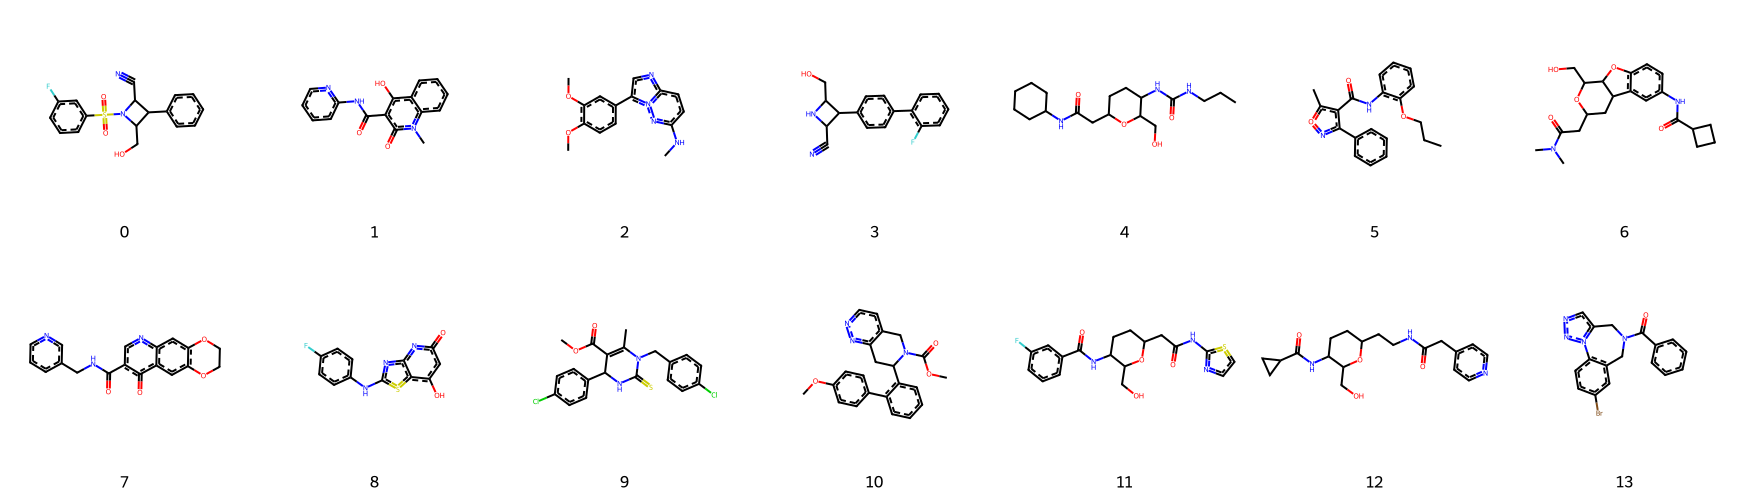

Loaded graphs: 479
Class split: [377 102]
Embeddings shape: (479, 2048)
Anchor index: 42 (target=1)
Removed graphs: 5
Remaining graphs: 474


,graph_index,target,cosine_to_anchor,is_anchor,removed
42,42,1,1.000000,True,False
9,9,1,0.893033,False,True
465,465,0,0.878926,False,True
477,477,1,0.877672,False,True
329,329,1,0.876791,False,True
133,133,0,0.868200,False,True
111,111,1,0.867983,False,False
70,70,1,0.864896,False,False
79,79,0,0.864567,False,False
236,236,0,0.862537,False,False


In [6]:
graphs, targets = build_dataset(
    dataset_type=DATASET_TYPE,
    dataset_size=DATASET_SIZE,
    size=MAX_NODE_SIZE,
    assay_id=ASSAY_ID,
)
print(f"Loaded graphs: {len(graphs)}")
if len(targets) > 0:
    bincount = np.bincount(np.asarray(targets, dtype=int)) if np.issubdtype(np.asarray(targets).dtype, np.integer) else None
    if bincount is not None:
        print(f"Class split: {bincount}")

graph_vectorizer, embeddings = compute_graph_embeddings(graphs, nbits=11)
print(f"Embeddings shape: {embeddings.shape}")

result = prune_by_anchor_similarity(
    graphs=graphs,
    targets=np.asarray(targets),
    embeddings=embeddings,
    k_remove=K_REMOVE,
    random_state=RANDOM_STATE,
    remove_anchor=REMOVE_ANCHOR,
)

print(f"Anchor index: {result['anchor_idx']} (target={result['anchor_target']})")
print(f"Removed graphs: {len(result['remove_indices'])}")
print(f"Remaining graphs: {len(result['pruned_graphs'])}")

display(result['summary'].head(12))



Anchor graph:


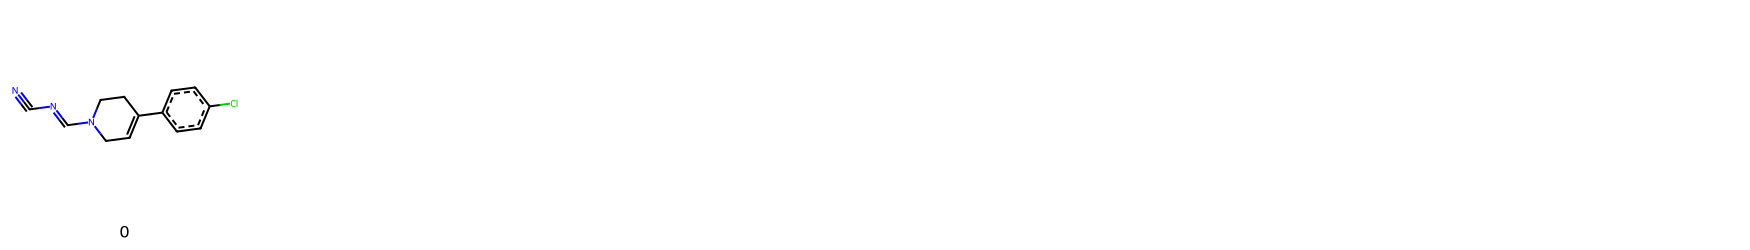

Removed top-5 most similar graphs:


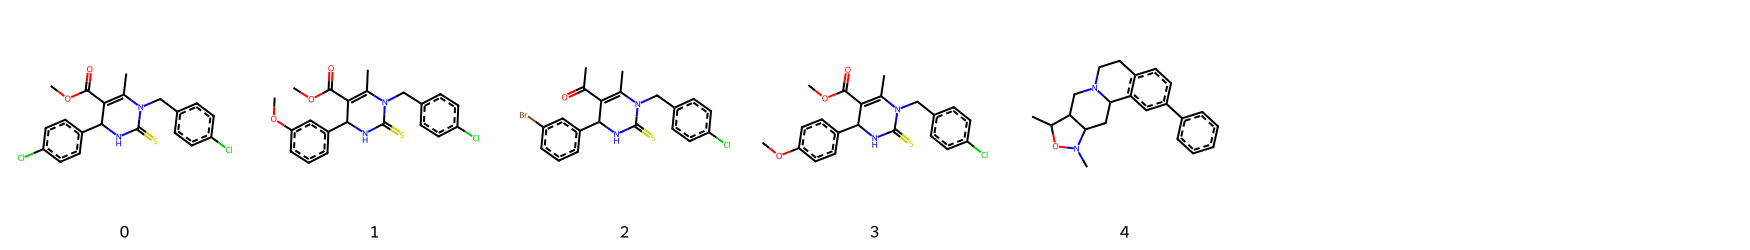

In [7]:
display_mode = infer_display_mode(graphs)

print("Anchor graph:")
plot_networkx_graphs([result['anchor_graph']], n_cols=1, mode=display_mode)

removed_graphs = [graphs[i] for i in result['remove_indices']]
print(f"Removed top-{len(removed_graphs)} most similar graphs:")
plot_networkx_graphs(removed_graphs, n_cols=max(1, len(removed_graphs)), mode=display_mode)


In [8]:
# Working dataset after similarity-based pruning
working_graphs = result['pruned_graphs']
working_targets = result['pruned_targets']
working_similarity_target = result['pruned_similarity_target']

print(f"working_graphs: {len(working_graphs)}")
print(f"working_targets: {len(working_targets)}")
print(f"working_similarity_target shape: {working_similarity_target.shape}")
print(f"cosine target range: [{working_similarity_target.min():.4f}, {working_similarity_target.max():.4f}]")


working_graphs: 474
working_targets: 474
working_similarity_target shape: (474,)
cosine target range: [0.6351, 1.0000]


## Strict CFG Experiment: Similarity to Hidden Target Graph

Train `EqMDecompositionalGraphGenerator` on the pruned dataset with the regression target
`working_similarity_target`, then generate with `desired_target=1.0` and `desired_target=0.7`
and compare average cosine similarity to the hidden anchor graph.


In [9]:
import sys
from pathlib import Path

for _root in [Path.cwd(), *Path.cwd().parents[:2]]:
    if (_root / 'eqm_decompositional_graph_generator').exists():
        _root_str = str(_root.resolve())
        if _root_str not in sys.path:
            sys.path.insert(0, _root_str)
        break
else:
    raise ModuleNotFoundError("Could not locate 'eqm_decompositional_graph_generator' package from current working directory.")

del _root, _root_str

from NSPPK.nsppk import NSPPK, NodeNSPPK
from AbstractGraph.abstract_graph_operators import compose, cycle, neighborhood, unlabel
from AbstractGraph.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
    WithinRangeFeasibilityEstimatorFromNumericalFunction,
)
from eqm_decompositional_graph_generator.node_engine import EqMDecompositionalNodeGenerator
from eqm_decompositional_graph_generator.graph_engine import (
    EqMDecompositionalGraphDecoder,
    EqMDecompositionalGraphGenerator,
)


In [ ]:
import dill as pickle

# CFG experiment configuration
GEN_NBITS = 11
GEN_VERBOSE = 2
GEN_MAX_EPOCHS = 120
GEN_BATCH_SIZE = 16
GEN_TOTAL_STEPS = 100


# Early stopping: require a meaningful relative improvement on val_total
EARLY_STOPPING_RELATIVE_DELTA = 1e-3  # 0.1%
EARLY_STOPPING_REFERENCE_VAL_TOTAL = 5.2e4
EARLY_STOPPING_MIN_DELTA = EARLY_STOPPING_REFERENCE_VAL_TOTAL * EARLY_STOPPING_RELATIVE_DELTA


REPO_ROOT = next(
    candidate.resolve()
    for candidate in [Path.cwd(), Path.cwd().parent]
    if (candidate / 'eqm_decompositional_graph_generator').exists()
)
MODEL_PATH = REPO_ROOT / '.artifacts' / 'saved_models' / 'similarity_graph_generator.pkl'

try:
    from notebooks.demo_pipeline_utils import build_graph_generator
except ModuleNotFoundError:
    from demo_pipeline_utils import build_graph_generator


def save_graph_generator(graph_generator, model_path=MODEL_PATH):
    model_path = Path(model_path)
    model_path.parent.mkdir(parents=True, exist_ok=True)
    with open(model_path, 'wb') as f:
        pickle.dump(graph_generator, f)
    print(f"Saved graph generator to {model_path}")
    return model_path


def load_graph_generator(model_path=MODEL_PATH):
    model_path = Path(model_path)
    if not model_path.exists():
        raise FileNotFoundError(f"Saved generator model not found: {model_path}")
    with open(model_path, 'rb') as f:
        loaded_generator = pickle.load(f)
    print(f"Loaded graph generator from {model_path}")
    return loaded_generator





def cosine_to_hidden_target(graphs_to_compare, hidden_graph, fitted_graph_vectorizer):
    if len(graphs_to_compare) == 0:
        return np.array([], dtype=float)
    hidden_embedding = np.asarray(fitted_graph_vectorizer.transform([hidden_graph]), dtype=np.float32)
    generated_embeddings = np.asarray(fitted_graph_vectorizer.transform(graphs_to_compare), dtype=np.float32)
    return cosine_similarity(generated_embeddings, hidden_embedding).ravel()


Training on 474 pruned graphs with similarity targets in [0.6351, 1.0000]
Fitting model on 474 graphs
Fitting feasibility estimator on 474 graphs
Supervision plan:
  node_labels: mode=learned, enabled. 9 node labels detected.
  edge_labels: mode=learned, enabled. 4 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed when locality_horizon=1.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 75528 pairs (50.00%) from 151056 total pairs (pos=50352, neg=100704, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon=1]: using pos=25176, neg=50352, positive_ratio=0.333.
Training conditional model on 474 graphs with up to 28 nodes each.
Using direct-edge supervision with 75528 labelled pairs.
Direct edge supervision enabled: horizon-1 edge presence wi

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Writing Lightning logs to /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/lightning_logs
Writing checkpoints to /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/checkpoints/eqm/EqMDecompositionalNodeGenerator_b11e317d02ee42fdbd9d1fea06735bcc


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                               ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layernorm_in                       │ LayerNorm  │  4.1 K │ train │     0 │
│ 1 │ linear_encoder_input_to_latent     │ Linear     │  262 K │ train │     0 │
│ 2 │ linear_encoder_condition_to_latent │ Linear     │  262 K │ train │     0 │
│ 3 │ shared_transformer                 │ ModuleList │  1.1 M │ train │     0 │
│ 4 │ potential_head                     │ Sequential │ 16.9 K │ train │     0 │
│ 5 │ degree_head                        │ Linear     │    645 │ train │     0 │
│ 6 │ exist_head                         │ Linear     │    129 │ train │     0 │
│ 7 │ node_label_head                    │ Linear     │  1.2 K │ train │     0 │
│ 8 │ edge_label_head                    │ EdgeMLP    │  132 K │ train │     0 │
│ 9 │ edge_head                          │ EdgeMLP    │  131 K │ train │     0 │
└───┴────────────────────────────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.9 M                                                                                                
Total estimated model params size (MB): 7                                                                          
Modules in train mode: 88                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 10/120 | ETA 0h 27m 43s:
  train total=  58224.0 |        eqm   51185.8 87.9% |        deg     905.3  1.6% |      exist     423.7  0.7% | node_label    3395.8  5.8% | edge_label     660.9  1.1% |       edge    1652.5  2.8% | dominant=eqm (87.9%)
  val   total=  57642.0 |        eqm   51149.6 88.7% |        deg     853.0  1.5% |      exist     458.3  0.8% | node_label    2966.9  5.1% | edge_label     579.5  1.0% |       edge    1634.7  2.8% | dominant=eqm (88.7%)
Epoch 20/120 | ETA 0h 23m 46s:
  train total=  56045.4 |        eqm   51203.0 91.4% |        deg     832.2  1.5% |      exist     382.4  0.7% | node_label    1475.5  2.6% | edge_label     535.3  1.0% |       edge    1617.0  2.9% | dominant=eqm (91.4%)
  val   total=  55313.0 |        eqm   51224.9 92.6% |        deg     784.0  1.4% |      exist     439.1  0.8% | node_label     817.9  1.5% | edge_label     457.1  0.8% |       edge    1589.9  2.9% | dominant=eqm (92.6%)
Epoch 30/120 | ETA 0h 21m 08s:
  train total=  55192.3

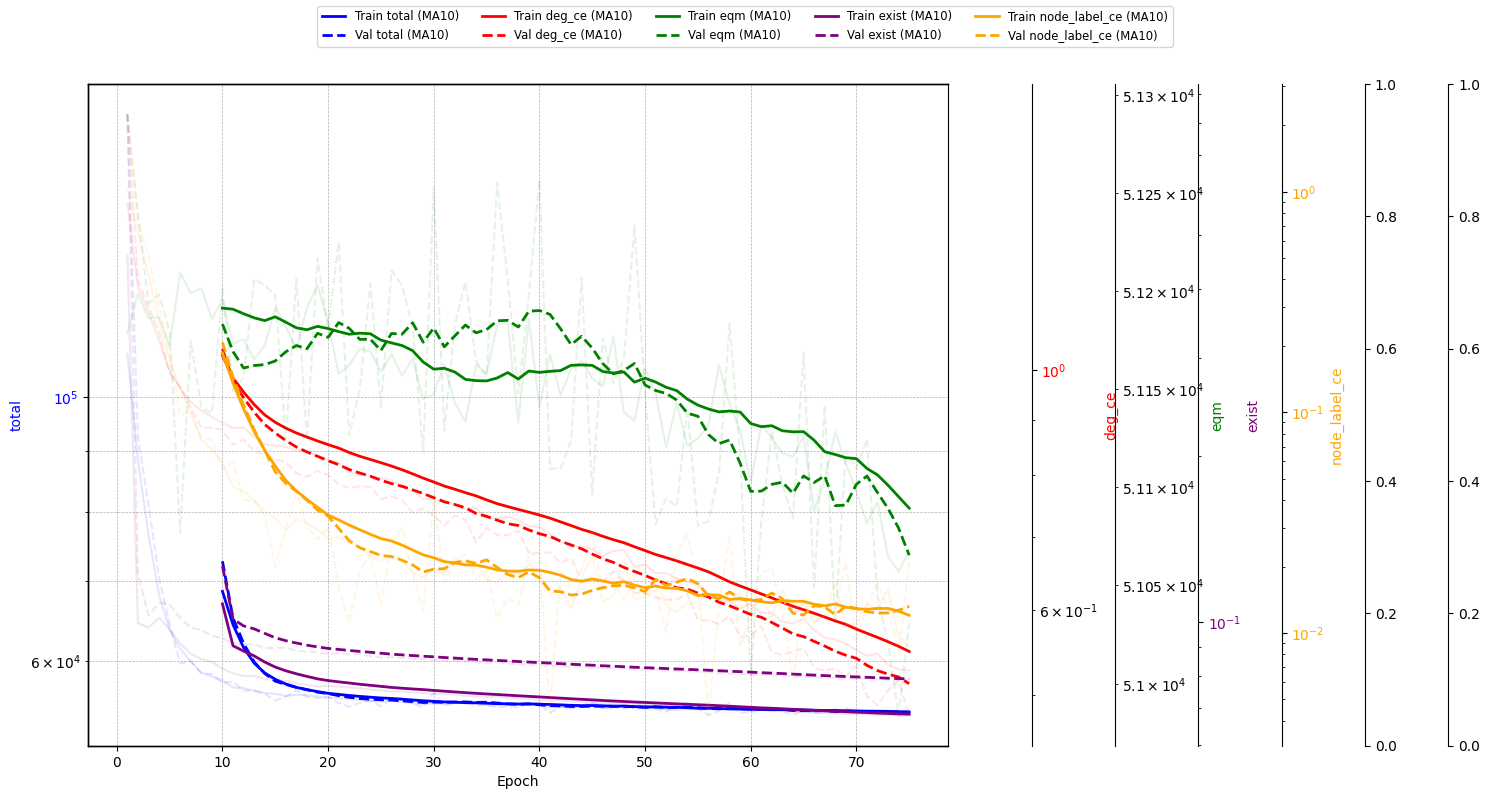

Restored best checkpoint from /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/checkpoints/eqm/EqMDecompositionalNodeGenerator_b11e317d02ee42fdbd9d1fea06735bcc/best-072-53977.5742.ckpt (best_epoch=73, val_total=53977.5742, stopped_epoch=76).
Saved graph generator to /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/saved_models/similarity_graph_generator.pkl
CPU times: user 2h 11min 20s, sys: 11min 1s, total: 2h 22min 21s
Wall time: 20min 5s


PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/saved_models/similarity_graph_generator.pkl')

In [11]:
%%time
similarity_graph_generator = build_graph_generator(
    nbits=GEN_NBITS,
    verbose=GEN_VERBOSE,
    maximum_epochs=GEN_MAX_EPOCHS,
    batch_size=GEN_BATCH_SIZE,
    total_steps=GEN_TOTAL_STEPS,
    early_stopping_monitor="val_eqm",
    early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
    lambda_degree_importance=1e3,
    lambda_node_exist_importance=5e3,
    lambda_node_label_importance=5e4,
    lambda_edge_label_importance=1e3,
    lambda_locality_importance=2e3,
    degree_temperature=1,
    eqm_sigma=0.2,
    sampling_step_size=0.05,
    langevin_noise_scale=0.0,
    cfg_condition_dropout_prob=0.1,
    cfg_null_target_strategy="zero",
    target_classification_max_distinct=20,
    locality_horizon=1,
    locality_sample_fraction=0.5,
    negative_sample_factor=1,
    locality_sampling_strategy="stratified_preserve",
    locality_target_positive_ratio=0.5,
    use_feasibility_filtering=True,
    max_feasibility_attempts=10,
    feasibility_candidates_per_attempt=4,
    feasibility_failure_mode="return_partial",
    artifact_root=REPO_ROOT / ".artifacts",
    checkpoint_root=REPO_ROOT / ".artifacts" / "checkpoints" / "eqm",
)

print(f"Training on {len(working_graphs)} pruned graphs with similarity targets in [{working_similarity_target.min():.4f}, {working_similarity_target.max():.4f}]")
_ = similarity_graph_generator.fit(
    working_graphs,
    targets=working_similarity_target,
)

# Save trained generator
save_graph_generator(similarity_graph_generator)


Loaded graph generator from /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/saved_models/similarity_graph_generator.pkl


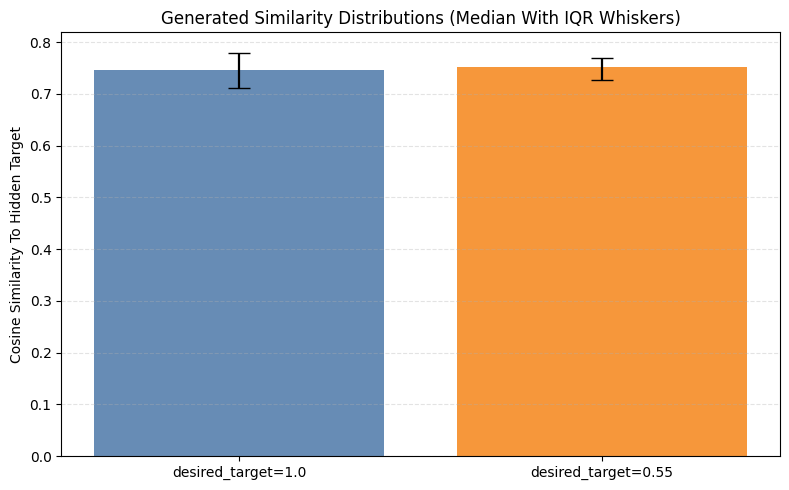

desired_target=1.0 -> n=8, median=0.7454, q1=0.7115, q3=0.7801
desired_target=0.55 -> n=8, median=0.7529, q1=0.7269, q3=0.7701
median(high) - median(low) = -0.0076


In [17]:
# Reload generator from disk before sampling
similarity_graph_generator = load_graph_generator(MODEL_PATH)


EVAL_N_SAMPLES = 8
EVAL_GUIDANCE_SCALE = 4.0
TARGET_HIGH = 1.0
TARGET_LOW = 0.55
FEASIBILITY_FILTERING = False

generated_high = similarity_graph_generator.sample_conditioned_on_random(
    working_graphs,
    n_samples=EVAL_N_SAMPLES,
    desired_target=TARGET_HIGH,
    guidance_scale=EVAL_GUIDANCE_SCALE,
    apply_feasibility_filtering=FEASIBILITY_FILTERING,
)

generated_low = similarity_graph_generator.sample_conditioned_on_random(
    working_graphs,
    n_samples=EVAL_N_SAMPLES,
    desired_target=TARGET_LOW,
    guidance_scale=EVAL_GUIDANCE_SCALE,
    apply_feasibility_filtering=FEASIBILITY_FILTERING,
)

# Similarity vectors for generated samples vs hidden target
sim_high = cosine_to_hidden_target(generated_high, result['anchor_graph'], graph_vectorizer)
sim_low = cosine_to_hidden_target(generated_low, result['anchor_graph'], graph_vectorizer)

# Plot + summary stats in one utility call
similarity_stats = plot_similarity_distribution_with_iqr(
    sim_high=sim_high,
    sim_low=sim_low,
    target_high=TARGET_HIGH,
    target_low=TARGET_LOW,
)


Anchor graph:


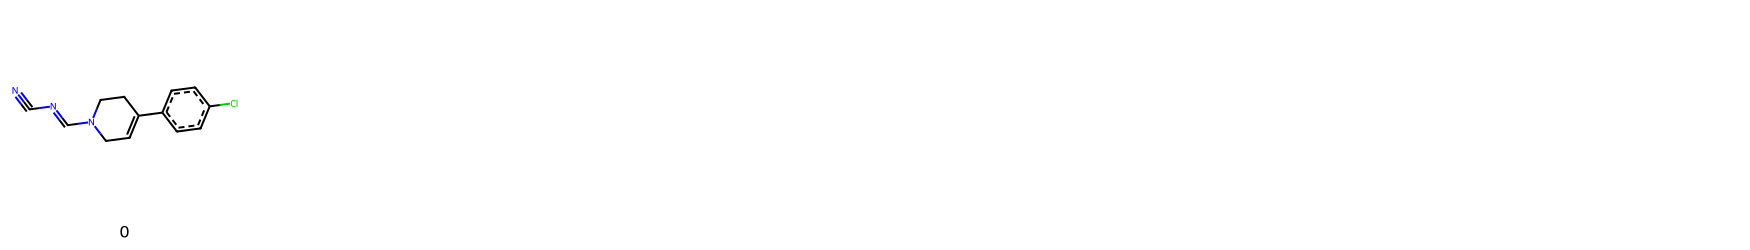

Sample generations for desired_target=1.0


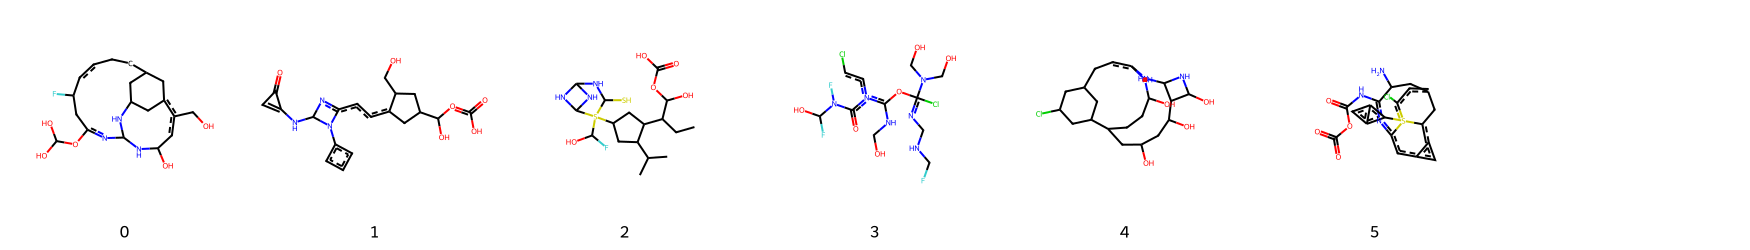

Sample generations for desired_target=0.7


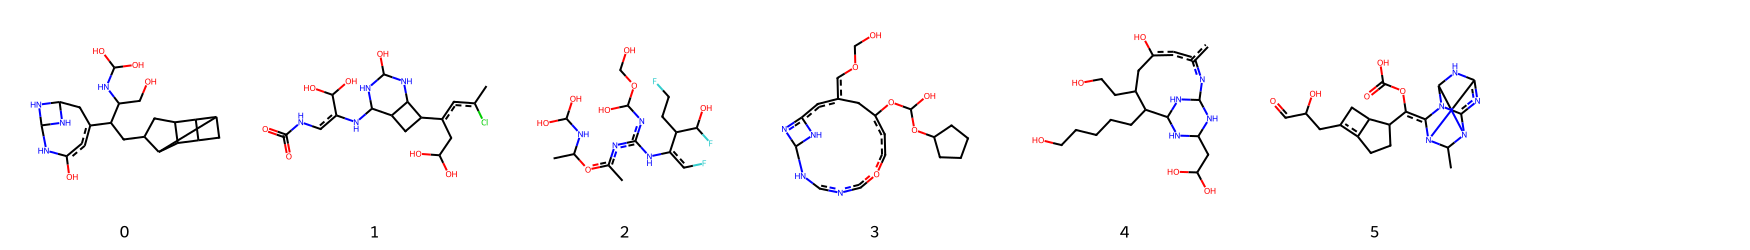

In [18]:
display_mode = infer_display_mode(working_graphs)

print("Anchor graph:")
plot_networkx_graphs([result['anchor_graph']], n_cols=1, mode=display_mode)

print('Sample generations for desired_target=1.0')
plot_networkx_graphs(generated_high[:6], n_cols=min(6, max(1, len(generated_high[:6]))), mode=display_mode)

print('Sample generations for desired_target=0.7')
plot_networkx_graphs(generated_low[:6], n_cols=min(6, max(1, len(generated_low[:6]))), mode=display_mode)